# Importing the data and selecting subset
The data is first imported from the SQLite file and converted into a pandas dataframe. After that, all N/A and duplicate records are dropped, and a the dataset is subsetted randomly. 

In [19]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect("./data/properties_cleaned.db")
df = pd.read_sql_query(f"SELECT * FROM properties", conn)
conn.close()

#['bedrooms', 'building_form', 'city', 'commercial_space',
# 'days_on_market', 'energy_efficient', 'energy_label', 'fixer_upper',
# 'has_balcony', 'has_garden', 'has_heat_pump', 'has_roof_terrace',
# 'has_solar_panels', 'latitude', 'living_area', 'longitude',
# 'national_monument', 'object_type', 'plot_area_m2', 'postcode4',
# 'price', 'province', 'publication_date', 'rooms', 'url', 'year_built',
# 'has_basement', 'has_attic', 'stories', 'addresses_per_km2', 'urbanization_level'],

print(len(df))
df = df.dropna()
print(len(df))
df = df.drop_duplicates()
print(len(df))
#df = df.sample(n=10000, random_state=1)

# Select subset
df = df[['price', 'bedrooms', 'building_form', 
         #'city', 
         'commercial_space',
         'days_on_market', 
         'energy_efficient', 'energy_label', 'fixer_upper',
         'has_balcony', 'has_garden', 'has_heat_pump', 'has_roof_terrace',
         'has_solar_panels', 'latitude', 'living_area', 'longitude',
         'national_monument', 
         'object_type', 'plot_area_m2', #'postcode4',
         'province', 
         'publication_date', 
         #'urbanization_level',
         'publication_date',
         'addresses_per_km2',
         'rooms', 'year_built',
         'has_basement', 'has_attic', 'stories']]



157563
144662
144662


# Preprocessing and analyzing the data prior to modeling
Before the model can be created, the data has to be preprocessed and analyzed for things such as multicollinearity.

## Converting datatypes
All columns have to be converted to the proper datatypes to allow modeling

In [20]:
# CATEGORY
df['building_form'] = df['building_form'].astype('category')
df['object_type'] = df['object_type'].astype('category')
df['province'] = df['province'].astype('category')

# Ordinal category for energy_label
df['energy_label'] = pd.Categorical(
    df['energy_label'],
    categories=['g', 'f', 'e', 'd', 'c', 'b', 'a'],
    ordered=True
)

# BOOL
df['has_balcony'] = df['has_balcony'].astype(bool)
df['has_garden'] = df['has_garden'].astype(bool)
df['has_heat_pump'] = df['has_heat_pump'].astype(bool)
df['has_roof_terrace'] = df['has_roof_terrace'].astype(bool)
df['has_solar_panels'] = df['has_solar_panels'].astype(bool)
df['has_basement'] = df['has_basement'].astype(bool)
df['has_attic'] = df['has_attic'].astype(bool)
df['fixer_upper'] = df['fixer_upper'].astype(bool)
df['energy_efficient'] = df['energy_efficient'].astype(bool)
df['commercial_space'] = df['commercial_space'].astype(bool)
df['national_monument'] = df['national_monument'].astype(bool)

# INT
df['rooms'] = df['rooms'].astype(int)
df['year_built'] = df['year_built'].astype(int)
df['living_area'] = df['living_area'].astype(int)
df['plot_area_m2'] = df['plot_area_m2'].astype(int)
df['days_on_market'] = df['days_on_market'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)
df['stories'] = df['stories'].astype(int)
df['addresses_per_km2'] = df['addresses_per_km2'].astype(int)
#df['urbanization_level'] = df['urbanization_level'].astype(int)

# FLOAT
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)
df['price'] = df['price'].str.replace('€', '').str.replace('.', '').astype(float)

# DATE
# Remove duplicate 'publication_date' column if it exists
if df.columns.duplicated().any():
    df = df.loc[:, ~df.columns.duplicated()]

# Convert to datetime
#df['publication_date'] = pd.to_datetime(df['publication_date'], format='%Y-%m-%d')

# Extract useful numeric features from publication_date
#df['pub_year'] = df['publication_date'].dt.year
#df['pub_month'] = df['publication_date'].dt.month
#df['pub_dayofweek'] = df['publication_date'].dt.dayofweek
#df['pub_dayofyear'] = df['publication_date'].dt.dayofyear

# Drop the original 'publication_date' column
df = df.drop(columns=['publication_date'])

# print data types
print(df.dtypes)

price                 float64
bedrooms                int64
building_form        category
commercial_space         bool
days_on_market          int64
energy_efficient         bool
energy_label         category
fixer_upper              bool
has_balcony              bool
has_garden               bool
has_heat_pump            bool
has_roof_terrace         bool
has_solar_panels         bool
latitude              float64
living_area             int64
longitude             float64
national_monument        bool
object_type          category
plot_area_m2            int64
province             category
addresses_per_km2       int64
rooms                   int64
year_built              int64
has_basement             bool
has_attic                bool
stories                 int64
dtype: object


In [12]:
print(len(df))

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Remove outliers for specified columns
for col in ['bedrooms', 'living_area', 'plot_area_m2', 'rooms', 'year_built', 'stories', 'price']:
    df = remove_outliers_iqr(df, col)
print(len(df))

144662
120601


## Check for Multicolinearity
Multicollinearity doesnt impact rf, but important for interpretting 

In [13]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_vars = df.select_dtypes(include=['number']).drop(columns='price')
X = add_constant(numeric_vars)  # A constant is added
 
# Compute VIF for each numeric feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)  # Sort by VIF values

print(vif_data)

              feature           VIF
0               const  17508.676255
8               rooms      5.631441
1            bedrooms      5.544181
4         living_area      2.870412
6        plot_area_m2      2.052847
7   addresses_per_km2      1.650498
10            stories      1.587029
9          year_built      1.293936
5           longitude      1.280733
3            latitude      1.128749
2      days_on_market      1.003159


The VIF values show signs of multicolliniearity for bedrooms and rooms. Therefore, the rooms variable will be converted to a non_bedroom_rooms variable. This will give the variable a different meaning, while still maintaining context.

In [14]:
if 'rooms' in df.columns:
    df['non_bedroom_rooms'] = df['rooms'] - df['bedrooms'].astype(int)
    df = df.drop(columns=['rooms'])

# XGBoost
XGBoost model

## Initial Model

In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

y = df['price']
X = pd.get_dummies(df.drop(columns=['price']), drop_first=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []
rmse_scores = []
r2_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    xgb = XGBRegressor(
        n_estimators=444,
        max_depth=9,
        learning_rate=0.052277267492428794,
        subsample=0.9947547746402069,
        colsample_bytree=0.7123738038749523,
        gamma=0.16280882494747453,
        min_child_weight=1,
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)

    #print("Train R^2: {:.3f}".format(r2_score(y_train, xgb.predict(X_train))))
    #print("Test R^2: {:.3f}".format(r2_score(y_test, y_pred)))
    #print()
    
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

print("MAE (mean ± std): {:.2f} ± {:.2f}".format(np.mean(mae_scores), np.std(mae_scores)))
print("RMSE (mean ± std): {:.2f} ± {:.2f}".format(np.mean(rmse_scores), np.std(rmse_scores)))
print("R^2 (mean ± std): {:.3f} ± {:.3f}".format(np.mean(r2_scores), np.std(r2_scores)))
print("MAPE (mean ± std): {:.2f} ± {:.2f}".format(np.mean(np.abs((y_test - y_pred) / y_test)), np.std(np.abs((y_test - y_pred) / y_test))))

# Store all scores in a dictionary
xgb_scores = {
    'mae': mae_scores,
    'rmse': rmse_scores,
    'r2': r2_scores
}

print(xgb_scores)

MAE (mean ± std): 32781.54 ± 95.15
RMSE (mean ± std): 45491.43 ± 187.23
R^2 (mean ± std): 0.886 ± 0.001
MAPE (mean ± std): 0.08 ± 0.08
{'mae': [32771.59316700178, 32934.4449455198, 32653.45132346082, 32825.43457419932, 32722.765622084888], 'rmse': [45536.73994619916, 45714.72068483032, 45426.617411708234, 45611.34522910794, 45167.720822733165], 'r2': [0.8850487032874457, 0.8844172359733483, 0.8868283319349588, 0.8859825534112078, 0.8877423871528166]}


In [35]:
# Save model to joblib file
import joblib
model_filename = 'xgb.joblib'
joblib.dump(xgb, model_filename)
print(f"Model saved to {model_filename}")


Model saved to xgb.joblib


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from scipy.stats import randint, uniform

# Define model
xgb = XGBRegressor(random_state=42, n_jobs=-1)

# Define hyperparameter search space
param_distributions = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.3),
    'min_child_weight': randint(1, 10)
}

scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,
    n_iter=50,
    scoring=scorer,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit search
random_search.fit(X, y)

# Best model and parameters
print("Best MAE (neg):", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best MAE (neg): -33663.158466985136
Best Parameters: {'colsample_bytree': 0.7123738038749523, 'gamma': 0.16280882494747453, 'learning_rate': 0.052277267492428794, 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 444, 'subsample': 0.9947547746402069}


## Feature Importance

### SHAP

/var/folders/dm/_tq0dqfd50b73lqr6vh5dcwh0000gn/T/ipykernel_49930/2778055861.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=10)


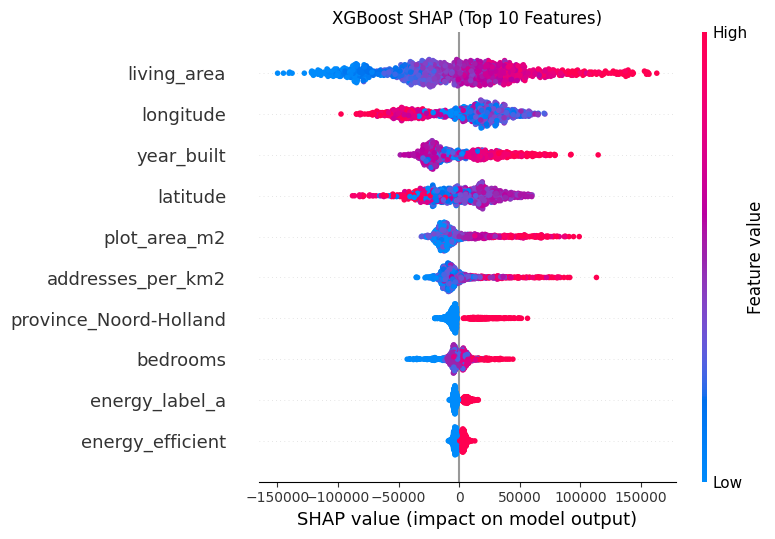


Global Feature Importance (Mean Absolute SHAP Values):
                    Feature  SHAP_Importance
11              living_area     46503.933594
12                longitude     29199.478516
16               year_built     23608.953125
10                 latitude     22380.832031
14             plot_area_m2     17227.673828
15        addresses_per_km2     13327.219727
35   province_Noord-Holland      8869.141602
0                  bedrooms      7347.004395
27           energy_label_a      4634.485840
3          energy_efficient      3490.061768
2            days_on_market      3447.287842
20        non_bedroom_rooms      2574.387939
37         province_Utrecht      2400.570557
19                  stories      2094.602783
31      province_Gelderland      1539.852905
9          has_solar_panels      1127.951660
25           energy_label_c       703.478027
6                has_garden       692.629944
18                has_attic       675.664368
5               has_balcony       659.120422

In [16]:
import shap
import numpy as np
import matplotlib.pyplot as plt

subset_idx = np.random.choice(X.index, size=1000, replace=False)
X_subset = X.loc[subset_idx]
y_subset = y.loc[subset_idx]

xgb.fit(X_subset, y_subset)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_subset)

# Get mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10_idx = np.argsort(mean_abs_shap)[-10:][::-1]
top10_features = X_subset.columns[top10_idx]


# Beeswarm plot for the top 10 features, with larger figure size
#plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values[:, top10_idx], X_subset.iloc[:, top10_idx], plot_type="dot", show=False)
plt.title("XGBoost SHAP (Top 10 Features)")
plt.tight_layout()
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=10)
plt.savefig("./plots/xgb_shap_10.png", dpi=300, bbox_inches='tight')
plt.show()

# Print Global Feature Importance (Mean absolute SHAP values)
feature_importance = pd.DataFrame({
    'Feature': X_subset.columns,
    'SHAP_Importance': mean_abs_shap
})
feature_importance = feature_importance.sort_values('SHAP_Importance', ascending=False)
print("\nGlobal Feature Importance (Mean Absolute SHAP Values):")
print(feature_importance)

import json
# Print top 10 features and their importance scores in JSON format
top_10_features = {row['Feature']: row['SHAP_Importance'] for row in feature_importance.head(10).to_dict('records')}
print("\nTop 10 Features and SHAP Values (JSON):")
print(json.dumps(top_10_features, indent=4))

In [17]:
import json
# Print top 10 features and their importance scores in JSON format
top_10_features = {row['Feature']: row['SHAP_Importance'] for row in feature_importance.to_dict('records')}
print("\nTop 10 Features and SHAP Values (JSON):")
print(json.dumps(top_10_features, indent=4))


Top 10 Features and SHAP Values (JSON):
{
    "living_area": 46503.93359375,
    "longitude": 29199.478515625,
    "year_built": 23608.953125,
    "latitude": 22380.83203125,
    "plot_area_m2": 17227.673828125,
    "addresses_per_km2": 13327.2197265625,
    "province_Noord-Holland": 8869.1416015625,
    "bedrooms": 7347.00439453125,
    "energy_label_a": 4634.48583984375,
    "energy_efficient": 3490.061767578125,
    "days_on_market": 3447.287841796875,
    "non_bedroom_rooms": 2574.387939453125,
    "province_Utrecht": 2400.570556640625,
    "stories": 2094.602783203125,
    "province_Gelderland": 1539.8529052734375,
    "has_solar_panels": 1127.95166015625,
    "energy_label_c": 703.47802734375,
    "has_garden": 692.6299438476562,
    "has_attic": 675.6643676757812,
    "has_balcony": 659.1204223632812,
    "province_Zuid-Holland": 574.1177368164062,
    "province_Noord-Brabant": 516.48974609375,
    "energy_label_b": 482.4020690917969,
    "province_Friesland": 476.1096801757812